## Graficos de Densidad comparativos entre las metaherusticas HC, SA y GWO
-  Autor: Germán Homero Morán Figueroa
- Descripción: En este notebook se realiza la comparación de las curvas de densidad para las metaherusticas HC, SA y GWO. En este caso se realizo la optimziación de 396 cultivos de maiz y se obtuvieron las practicas de manejo agricola que maximizan el rendimeinto del cultivo.

- Salida: Curvas de densidad comparativas de los algortimos de optimización
    - HC
    - SA
    - GWO

In [7]:
#  Librerias y dependencias
# ==============================================================================
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter



### 1. Lectura datos

se realiza la lectura de los datos obtenidos en el proceso de obtimización en este caso es la ganancia de cada evento

In [ ]:
# Se cargan los archivos desde resultados finales
# =====================================================
hc= pd.read_csv("resultados_best_fitness_hc_0_400.csv")
sa = pd.read_csv("resultados_best_fitness_sa_0_400.csv")
#gwo = pd.read_csv("resultados_best_fitness_gwo_modify_0_400.csv")
gwo = pd.read_csv("resultados_combinados_0_400.csv")
ganancia = pd.read_csv("real_ganancia_0_400.csv")

### 2. Graficos o distribuciones de Densidad

In [5]:
# Lectura de los datset
data1 = hc.Best_Fitness_Promedio
data2 = sa.Best_Fitness_Promedio

# Crear la figura con subgráficos
fig = make_subplots(rows=1, cols=2, subplot_titles=("📊 Distribución HC", "📊 Distribución SA"))

# Crear los gráficos de densidad
trace1 = ff.create_distplot([data1], group_labels=["Distribución HC"], show_hist=False, colors=["#1f77b4"]).data[0]
trace2 = ff.create_distplot([data2], group_labels=["Distribución SA"], show_hist=False, colors=["#ff7f0e"]).data[0]

# Extraer los valores de x e y para rellenar el área
x1, y1 = trace1.x, trace1.y
x2, y2 = trace2.x, trace2.y

# Crear trazos rellenos
fill_trace1 = go.Scatter(x=x1, y=y1, fill='tozeroy', mode='lines', line=dict(color='#1f77b4', width=3), name="Distribución 1")
fill_trace2 = go.Scatter(x=x2, y=y2, fill='tozeroy', mode='lines', line=dict(color='#ff7f0e', width=3), name="Distribución 2")

# Agregar los trazos a la figura
fig.add_trace(fill_trace1, row=1, col=1)
fig.add_trace(fill_trace2, row=1, col=2)

# Personalización del diseño
fig.update_layout(
    title_text="📈 Comparación de Distribuciones de Densidad",
    title_x=0.5,
    showlegend=False,
    plot_bgcolor="rgba(245, 245, 250, 1)",
    font=dict(family="Arial, sans-serif", size=14, color="black")
)

# Ajustar el estilo de los ejes
fig.update_xaxes(title_text="Ganancia",  gridcolor="lightgrey")
fig.update_yaxes(title_text="Densidad" ,gridcolor="lightgrey")

# Mostrar gráfico
fig.show()






In [8]:
# verificación de resultados best fitness HC
hc.Best_Fitness_Promedio

,Best_Fitness_Promedio
0,14434604.45
1,12785798.51
2,14604254.75
3,14970359.38
4,15022611.38
...,...
395,17234391.53
396,19784810.32
397,19114399.41
398,16932236.95


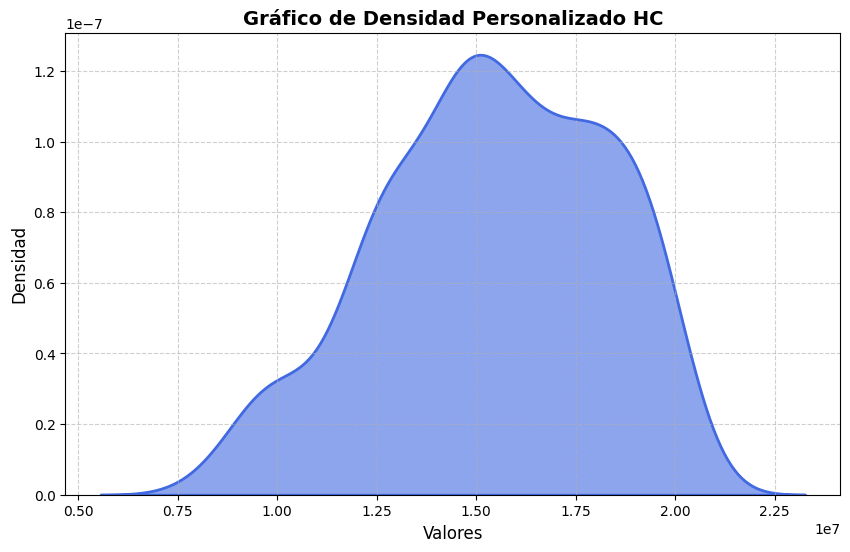

In [10]:
'''
   Se crean los graficos de densidad personalizados para los resultados
   de fitness(Ganancia) de HC
'''
# Crear figura y ejes
plt.figure(figsize=(10, 6))

# Crear gráfico de densidad con personalización
sns.kdeplot(hc.Best_Fitness_Promedio, fill=True, color="royalblue", linewidth=2, alpha=0.6)

# Personalizar título y etiquetas
plt.title("Gráfico de Densidad Personalizado HC", fontsize=14, fontweight='bold')
plt.xlabel("Valores", fontsize=12)
plt.ylabel("Densidad", fontsize=12)

# Agregar cuadrícula
plt.grid(True, linestyle="--", alpha=0.6)

# Mostrar gráfico
plt.show()


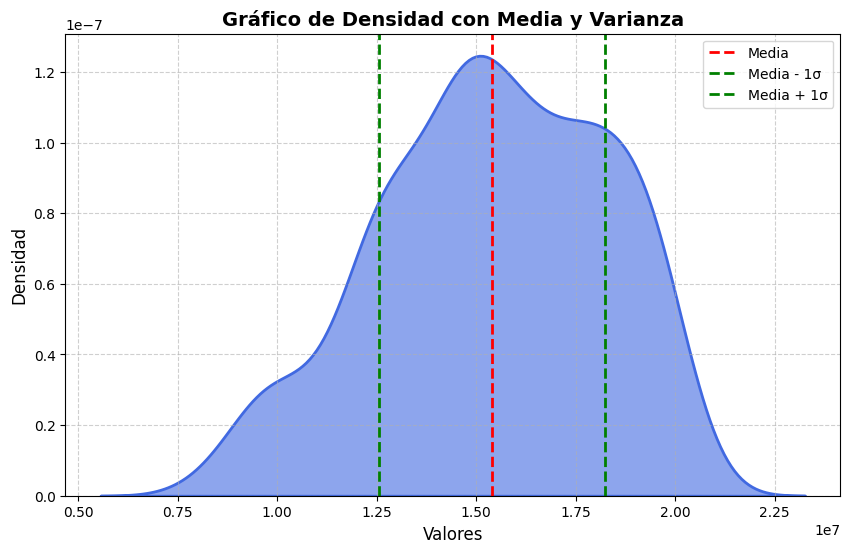

In [11]:
'''
  Se personaliza el grafico agregando la media y varianza de los datos
'''

# Suponiendo que hc.Best_Fitness_Promedio es un array o Serie de pandas
datos = hc.Best_Fitness_Promedio

# Calcular media y desviación estándar
media = np.mean(datos)
std = np.std(datos)

# Crear figura y ejes
plt.figure(figsize=(10, 6))

# Crear gráfico de densidad con personalización
sns.kdeplot(datos, fill=True, color="royalblue", linewidth=2, alpha=0.6)

# Agregar líneas verticales para la media y la varianza (1 desviación estándar)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label='Media')
plt.axvline(media - std, color='green', linestyle='--', linewidth=2, label='Media - 1σ')
plt.axvline(media + std, color='green', linestyle='--', linewidth=2, label='Media + 1σ')



# Personalizar título y etiquetas
plt.title("Gráfico de Densidad con Media y Varianza", fontsize=14, fontweight='bold')
plt.xlabel("Valores", fontsize=12)
plt.ylabel("Densidad", fontsize=12)

# Agregar cuadrícula
plt.grid(True, linestyle="--", alpha=0.6)

# Agregar leyenda
plt.legend()

# Mostrar gráfico
plt.show()



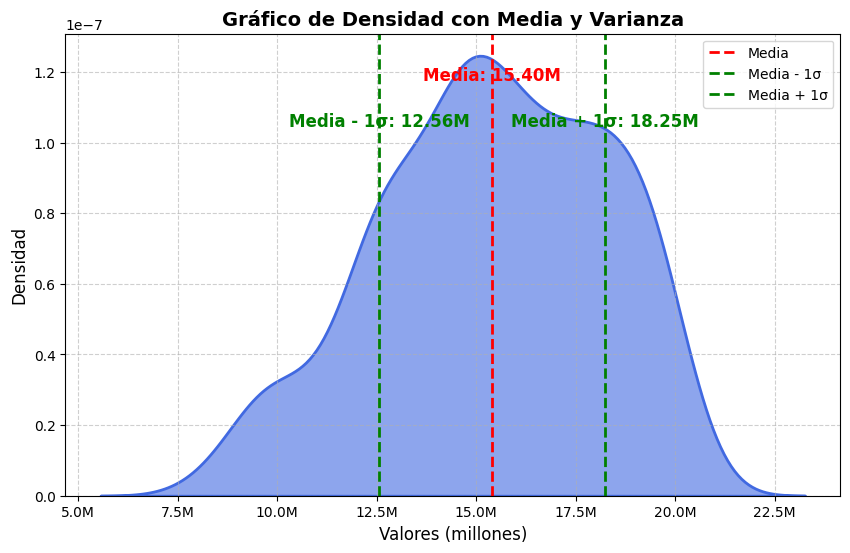

In [12]:


# Suponiendo que hc.Best_Fitness_Promedio es un array o Serie de pandas
datos = hc.Best_Fitness_Promedio

# Calcular media y desviación estándar
media = np.mean(datos)
std = np.std(datos)

# Función para formatear los valores en millones
def millones(x, pos):
    return f'{x/1e6:.1f}M'  # Divide por 1e6 y muestra un decimal

# Crear figura y ejes
plt.figure(figsize=(10, 6))

# Crear gráfico de densidad con personalización
sns.kdeplot(datos, fill=True, color="royalblue", linewidth=2, alpha=0.6)

# Agregar líneas verticales para la media y la varianza (1 desviación estándar)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label='Media')
plt.axvline(media - std, color='green', linestyle='--', linewidth=2, label='Media - 1σ')
plt.axvline(media + std, color='green', linestyle='--', linewidth=2, label='Media + 1σ')

# Agregar etiquetas en las líneas
plt.text(media, plt.ylim()[1] * 0.9, f'Media: {media/1e6:.2f}M', color='red', fontsize=12, ha='center', fontweight='bold')
plt.text(media - std, plt.ylim()[1] * 0.8, f'Media - 1σ: {(media - std)/1e6:.2f}M', color='green', fontsize=12, ha='center', fontweight='bold')
plt.text(media + std, plt.ylim()[1] * 0.8, f'Media + 1σ: {(media + std)/1e6:.2f}M', color='green', fontsize=12, ha='center', fontweight='bold')

# Personalizar título y etiquetas
plt.title("Gráfico de Densidad con Media y Varianza", fontsize=14, fontweight='bold')
plt.xlabel("Valores (millones)", fontsize=12)
plt.ylabel("Densidad", fontsize=12)

# Aplicar el formato en el eje X
plt.gca().xaxis.set_major_formatter(FuncFormatter(millones))

# Agregar cuadrícula
plt.grid(True, linestyle="--", alpha=0.6)

# Agregar leyenda
plt.legend()

# Mostrar gráfico
plt.show()


### 3. Grafico de Densidad para los resultadsos de HC


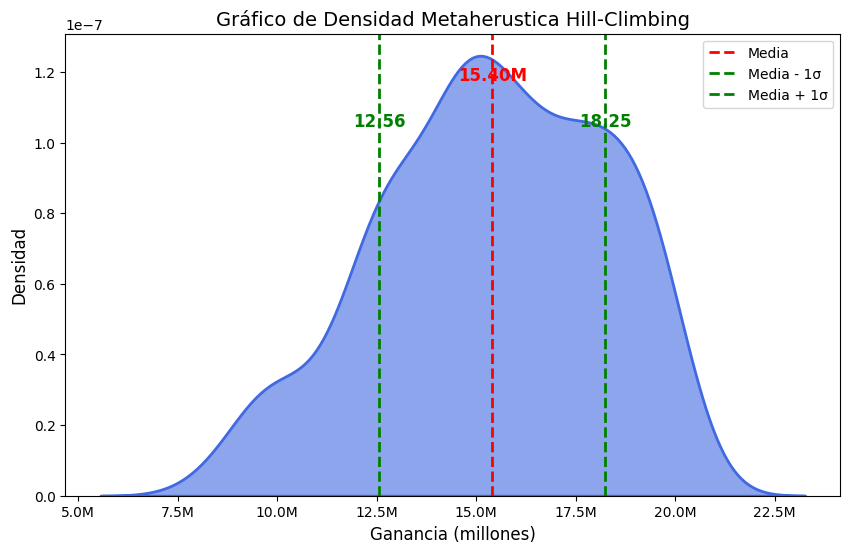

In [ ]:

# Suponiendo que hc.Best_Fitness_Promedio es un array o Serie de pandas
datos = hc.Best_Fitness_Promedio

# Calcular media y desviación estándar
media = np.mean(datos)
std = np.std(datos)

# Función para formatear los valores en millones
def millones(x, pos):
    return f'{x/1e6:.1f}M'  # Divide por 1e6 y muestra un decimal

# Crear figura y ejes
plt.figure(figsize=(10, 6))

# Crear gráfico de densidad con personalización
sns.kdeplot(datos, fill=True, color="royalblue", linewidth=2, alpha=0.6)

# Agregar líneas verticales para la media y la varianza (1 desviación estándar)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label='Media')
plt.axvline(media - std, color='green', linestyle='--', linewidth=2, label='Media - 1σ')
plt.axvline(media + std, color='green', linestyle='--', linewidth=2, label='Media + 1σ')

# Agregar etiquetas en las líneas
plt.text(media, plt.ylim()[1] * 0.9, f'{media/1e6:.2f}M', color='red', fontsize=12, ha='center', fontweight='bold')
plt.text(media - std, plt.ylim()[1] * 0.8, f'{(media - std)/1e6:.2f}', color='green', fontsize=12, ha='center', fontweight='bold')
plt.text(media + std, plt.ylim()[1] * 0.8, f'{(media + std)/1e6:.2f}', color='green', fontsize=12, ha='center', fontweight='bold')

# Personalizar título y etiquetas
plt.title("Gráfico de Densidad Metaherustica Hill-Climbing", fontsize=14)
plt.xlabel("Ganancia (millones)", fontsize=12)
plt.ylabel("Densidad", fontsize=12)

# Aplicar el formato en el eje X
plt.gca().xaxis.set_major_formatter(FuncFormatter(millones))



# Quitar la cuadrícula de fondo
plt.grid(False)

# Agregar leyenda
plt.legend()

# Guardar la imagen como PNG con alta resolución
plt.savefig("grafico_densidad.png", dpi=300, bbox_inches='tight')

# Mostrar gráfico
plt.show()

### 4. Grafico de Densidad para los resultados de Simuling Aneling (SA)

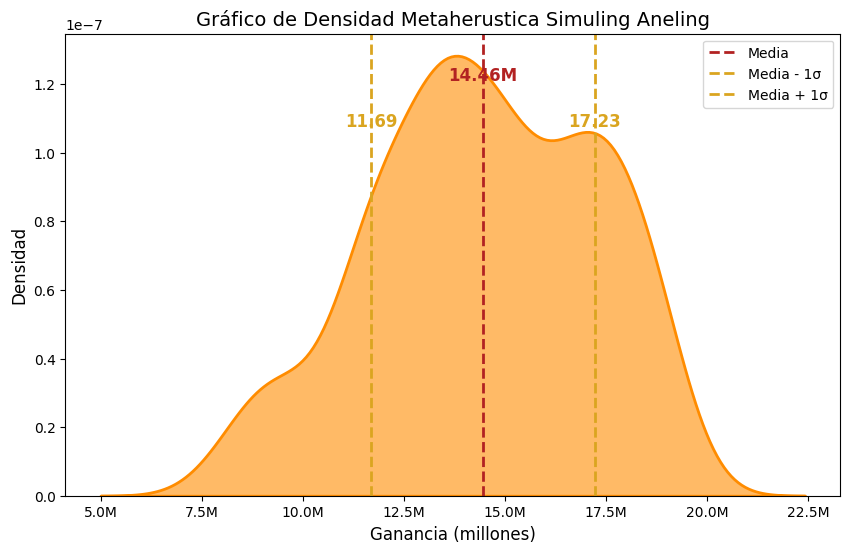

In [13]:
# Suponiendo que hc.Best_Fitness_Promedio es un array o Serie de pandas
datos = sa.Best_Fitness_Promedio

# Calcular media y desviación estándar
media = np.mean(datos)
std = np.std(datos)

# Función para formatear los valores en millones
def millones(x, pos):
    return f'{x/1e6:.1f}M'  # Divide por 1e6 y muestra un decimal

# Crear figura y ejes
plt.figure(figsize=(10, 6))

# Crear gráfico de densidad con personalización
sns.kdeplot(datos, fill=True, color="darkorange", linewidth=2, alpha=0.6)

# Agregar líneas verticales para la media y la varianza con colores mejorados
plt.axvline(media, color='#B22222', linestyle='--', linewidth=2, label='Media')  # Rojo oscuro
plt.axvline(media - std, color='#DAA520', linestyle='--', linewidth=2, label='Media - 1σ')  # Azul petróleo
plt.axvline(media + std, color='#DAA520', linestyle='--', linewidth=2, label='Media + 1σ')  # Azul petróleo

# Agregar etiquetas en las líneas
plt.text(media, plt.ylim()[1] * 0.9, f'{media/1e6:.2f}M', color='#B22222', fontsize=12, ha='center', fontweight='bold')
plt.text(media - std, plt.ylim()[1] * 0.8, f'{(media - std)/1e6:.2f}', color='#DAA520', fontsize=12, ha='center', fontweight='bold')
plt.text(media + std, plt.ylim()[1] * 0.8, f'{(media + std)/1e6:.2f}', color='#DAA520', fontsize=12, ha='center', fontweight='bold')

# Personalizar título y etiquetas
plt.title("Gráfico de Densidad Metaherustica Simuling Aneling", fontsize=14)
plt.xlabel("Ganancia (millones)", fontsize=12)
plt.ylabel("Densidad", fontsize=12)

# Aplicar el formato en el eje X
plt.gca().xaxis.set_major_formatter(FuncFormatter(millones))



# Quitar la cuadrícula de fondo
plt.grid(False)

# Agregar leyenda
plt.legend()

# Guardar la imagen como PNG con alta resolución
plt.savefig("grafico_densidad_sa.png", dpi=300, bbox_inches='tight')

# Mostrar gráfico
plt.show()

### 5. Grafico de Densidad para los resultadsos de GWO

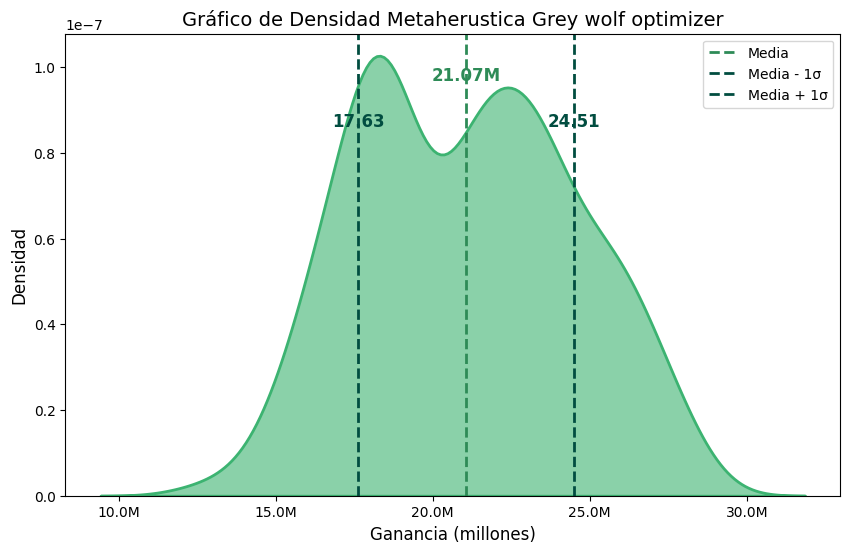

In [ ]:

# Suponiendo que hc.Best_Fitness_Promedio es un array o Serie de pandas
datos = gwo.Best_Fitness_Promedio

# Calcular media y desviación estándar
media = np.mean(datos)
std = np.std(datos)

# Función para formatear los valores en millones
def millones(x, pos):
    return f'{x/1e6:.1f}M'  # Divide por 1e6 y muestra un decimal

# Crear figura y ejes
plt.figure(figsize=(10, 6))

# Crear gráfico de densidad con personalización
sns.kdeplot(datos, fill=True, color="#3CB371", linewidth=2, alpha=0.6)

# Agregar líneas verticales para la media y la varianza con colores mejorados
plt.axvline(media, color='#2E8B57', linestyle='--', linewidth=2, label='Media')  # Rojo oscuro
plt.axvline(media - std, color='#014D40', linestyle='--', linewidth=2, label='Media - 1σ')  # Azul petróleo
plt.axvline(media + std, color='#014D40', linestyle='--', linewidth=2, label='Media + 1σ')  # Azul petróleo

# Agregar etiquetas en las líneas
plt.text(media, plt.ylim()[1] * 0.9, f'{media/1e6:.2f}M', color='#2E8B57', fontsize=12, ha='center', fontweight='bold')
plt.text(media - std, plt.ylim()[1] * 0.8, f'{(media - std)/1e6:.2f}', color='#014D40', fontsize=12, ha='center', fontweight='bold')
plt.text(media + std, plt.ylim()[1] * 0.8, f'{(media + std)/1e6:.2f}', color='#014D40', fontsize=12, ha='center', fontweight='bold')

# Personalizar título y etiquetas
plt.title("Gráfico de Densidad Metaherustica Grey wolf optimizer", fontsize=14)
plt.xlabel("Ganancia (millones)", fontsize=12)
plt.ylabel("Densidad", fontsize=12)

# Aplicar el formato en el eje X
plt.gca().xaxis.set_major_formatter(FuncFormatter(millones))



# Quitar la cuadrícula de fondo
plt.grid(False)

# Agregar leyenda
plt.legend()

# Guardar la imagen como PNG con alta resolución
plt.savefig("grafico_densidad_gwo.png", dpi=300, bbox_inches='tight')

# Mostrar gráfico
plt.show()

In [ ]:
datos

,Best_Fitness_Promedio
0,17720217.30
1,16938501.84
2,18271647.11
3,18262281.91
4,18216323.74
...,...
391,20651259.74
392,22997585.09
393,22771873.20
394,18501425.02


In [ ]:
ganancia.Ganacia

,Ganacia
0,9678225.61
1,9215912.01
2,10452945.69
3,10320121.72
4,10206822.73
...,...
391,13295976.87
392,15877753.24
393,15175984.74
394,12175170.86


### 6. Graficos de densidad para  GWO vs rendimiento real

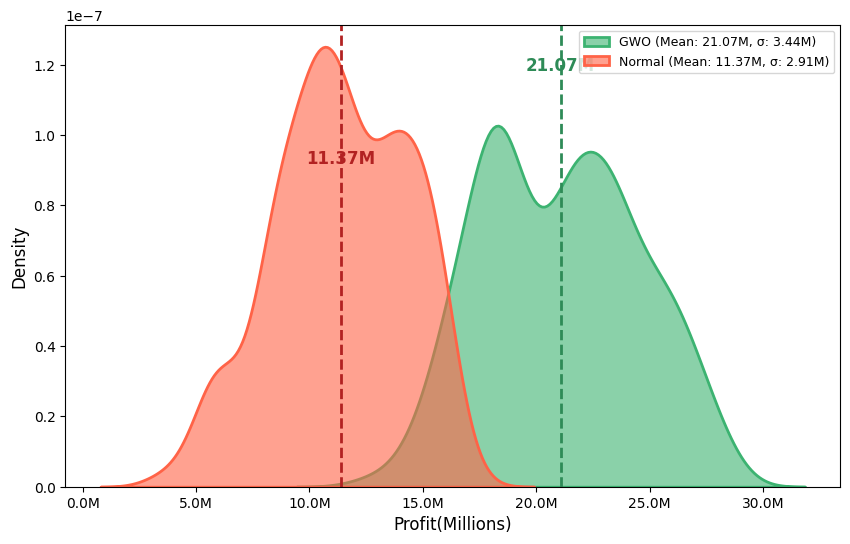

In [14]:

# Datos originales
datos = gwo.Best_Fitness_Promedio

# Segundo conjunto de datos (debes definirlo)
otro_datos = ganancia.Ganacia

# Calcular estadísticas
media = np.mean(datos)
std = np.std(datos)

media_otro = np.mean(otro_datos)
std_otro = np.std(otro_datos)

# Función para formatear los valores en millones
def millones(x, pos):
    return f'{x/1e6:.1f}M'

# Crear figura y ejes
plt.figure(figsize=(10, 6))

# Gráfico de densidad del primer conjunto de datos
sns.kdeplot(datos, fill=True, color="#3CB371", linewidth=2, alpha=0.6, label=f"GWO (Mean: {media/1e6:.2f}M, σ: {std/1e6:.2f}M)")

# Gráfico de densidad del segundo conjunto de datos
sns.kdeplot(otro_datos, fill=True, color="#FF6347", linewidth=2, alpha=0.6, label=f"Normal (Mean: {media_otro/1e6:.2f}M, σ: {std_otro/1e6:.2f}M)")  # Tomate

# Líneas verticales para la media y la varianza del primer conjunto
plt.axvline(media, color='#2E8B57', linestyle='--', linewidth=2)


# Líneas verticales para la media y la varianza del segundo conjunto
plt.axvline(media_otro, color='#B22222', linestyle='--', linewidth=2)  # Rojo fuego


# Agregar etiquetas en las líneas
plt.text(media, plt.ylim()[1] * 0.9, f'{media/1e6:.2f}M', color='#2E8B57', fontsize=12, ha='center', fontweight='bold')


plt.text(media_otro, plt.ylim()[1] * 0.7, f'{media_otro/1e6:.2f}M', color='#B22222', fontsize=12, ha='center', fontweight='bold')


# Personalizar título y etiquetas
#plt.title("Gráfico de Densidad - GWO vs HC", fontsize=14)
plt.xlabel("Profit(Millions)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Aplicar formato en el eje X
plt.gca().xaxis.set_major_formatter(FuncFormatter(millones))

# Quitar la cuadrícula de fondo
plt.grid(False)

# Agregar leyenda
plt.legend()
#
plt.legend(fontsize=9)  # Cambia el valor si quieres más pequeño
# Guardar la imagen
plt.savefig("grafico_densidad_comparativo_rela_vs_gwo_english.png", dpi=300, bbox_inches='tight')

# Mostrar gráfico
plt.show()


### 7. Graficos de densidad combinados en una misma grafica  para SA, HC y GWO

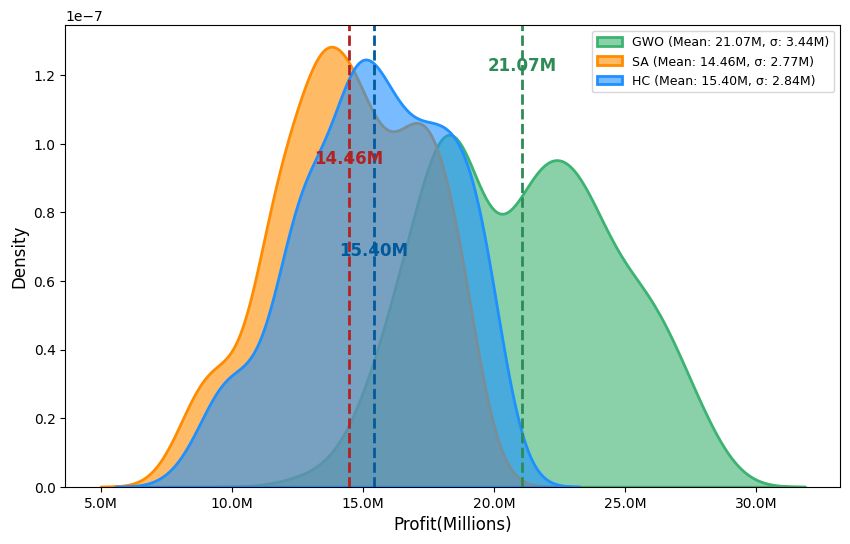

In [15]:

# Datos originales
datos_hc = hc.Best_Fitness_Promedio

# Segundo conjunto de datos
datos_sa = sa.Best_Fitness_Promedio

# Tercer conjunto de datos (debes definirlo)
datos_gwo = gwo.Best_Fitness_Promedio

# Calcular estadísticas
media_gwo = np.mean(datos_gwo)
std_gwo = np.std(datos_gwo)

media_sa = np.mean(datos_sa)
std_sa = np.std(datos_sa)

media_hc = np.mean(datos_hc)
std_hc = np.std(datos_hc)

# Función para formatear los valores en millones
def millones(x, pos):
    return f'{x/1e6:.1f}M'

# Crear figura y ejes
plt.figure(figsize=(10, 6))

# Gráfico de densidad del primer conjunto de datos (GWO)
sns.kdeplot(datos_gwo, fill=True, color="#3CB371", linewidth=2, alpha=0.6,
            label=f"GWO (Mean: {media_gwo/1e6:.2f}M, σ: {std_gwo/1e6:.2f}M)")

# Gráfico de densidad del segundo conjunto de datos (SA)
sns.kdeplot(datos_sa, fill=True, color="darkorange", linewidth=2, alpha=0.6,
            label=f"SA (Mean: {media_sa/1e6:.2f}M, σ: {std_sa/1e6:.2f}M)")

# Gráfico de densidad del tercer conjunto de datos (HC)
sns.kdeplot(datos_hc, fill=True, color="#1E90FF", linewidth=2, alpha=0.6,
            label=f"HC (Mean: {media_hc/1e6:.2f}M, σ: {std_hc/1e6:.2f}M)")

# Líneas verticales para las medias
plt.axvline(media_gwo, color='#2E8B57', linestyle='--', linewidth=2)
plt.axvline(media_sa, color='#B22222', linestyle='--', linewidth=2)
plt.axvline(media_hc, color='#005A9C', linestyle='--', linewidth=2)

# Agregar etiquetas en las líneas de media
plt.text(media_gwo, plt.ylim()[1] * 0.9, f'{media_gwo/1e6:.2f}M', color='#2E8B57', fontsize=12, ha='center', fontweight='bold')
plt.text(media_sa, plt.ylim()[1] * 0.7, f'{media_sa/1e6:.2f}M', color='#B22222', fontsize=12, ha='center', fontweight='bold')
plt.text(media_hc, plt.ylim()[1] * 0.5, f'{media_hc/1e6:.2f}M', color='#005A9C', fontsize=12, ha='center', fontweight='bold')

# Personalizar etiquetas
plt.xlabel("Profit(Millions)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Aplicar formato en el eje X
plt.gca().xaxis.set_major_formatter(FuncFormatter(millones))

# Quitar la cuadrícula de fondo
plt.grid(False)

# Agregar leyenda
plt.legend(fontsize=9)

# Guardar la imagen
plt.savefig("grafico_densidad_comparativo_english.png", dpi=300, bbox_inches='tight')

# Mostrar gráfico
plt.show()
